# tACS Bandit EEG Analyses (v2)

Tier 2 EEG analysis notebook for: *Examining the effects of theta-tACS over left DLPFC on reward-based learning across the adult lifespan*

This notebook handles artifact removal, spectral parameterization, individual theta frequency (ITF) extraction, and cross-run comparisons. It imports shared configuration from the behavioral analysis notebook and operates on NIC2 output files (.easy, .info, _IMP.txt).

**v2 Updates:**
- Added group-level batch processing for all subjects
- Added earclip vs. no-earclip reference comparison diagnostics
- Added signal quality metrics to investigate reference effects

**Key limitations:**
- Stimulation channels (F3, Fp1, FCz, FT7) blanked by NIC2 on all runs
- Only 3 EEG-only channels available (F4, P4, P3)
- LSL task markers not reaching NIC2 trigger channel
- For participants without earclip: software average re-referencing applied across 3 channels

## 0. Setup and Configuration

In [3]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import signal, stats
from pathlib import Path
from specparam import SpectralModel

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='loadtxt: input contained no data')

# --- Path configuration ---
REPO_ROOT = Path('..').resolve()
EEG_DIR = REPO_ROOT / 'data' / 'nic' / 'raw'

# --- Subject tracker ---
# Add new subjects here as they are collected
# earclip=True means CMS/DRL ear clip electrode was used
SUBJECT_INFO = {
    '10886': {'counterbalance': 'B', 'earclip': False},
    '10998': {'counterbalance': 'B', 'earclip': False},
    '11773': {'counterbalance': 'B', 'earclip': False},
    '10656': {'counterbalance': 'A', 'earclip': False},
    '10951': {'counterbalance': 'A', 'earclip': False},
    '10418': {'counterbalance': 'B', 'earclip': False},
    '10636': {'counterbalance': 'B', 'earclip': True},
    '11318': {'counterbalance': 'B', 'earclip': True},
    '10369': {'counterbalance': 'B', 'earclip': True}
}

# --- Run structure ---
# Maps run number to condition for each counterbalance order.
# Order A: Active on runs 2-3, Sham on runs 6-7
# Order B: Sham on runs 2-3, Active on runs 6-7
# Runs 1,5 = baseline; Runs 4,8 = post-stimulation baseline
RUN_CONDITIONS = {
    'A': {1: 'baseline', 2: 'active', 3: 'active', 4: 'post',
          5: 'baseline', 6: 'sham', 7: 'sham', 8: 'post'},
    'B': {1: 'baseline', 2: 'sham', 3: 'sham', 4: 'post',
          5: 'baseline', 6: 'active', 7: 'active', 8: 'post'},
}

# --- EEG constants ---
FS = 500                    # Sampling rate (Hz)
CH_LABELS = ['F3', 'Fp1', 'FCz', 'FT7', 'F4', 'P4', 'P3', 'Ch8']
STIM_CH_IDX = [0, 1, 2, 3]  # Channels used for stimulation (blanked by NIC2)
EEG_CH_IDX = [4, 5, 6]      # EEG-only recording channels
EEG_CH_LABELS = ['F4', 'P4', 'P3']
TACS_FREQ = 6.0             # Stimulation frequency (Hz)

# --- Frequency band definitions ---
BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 50),
}

print(f'Repository root: {REPO_ROOT}')
print(f'EEG directory: {EEG_DIR}')
print(f'Subjects in tracker: {list(SUBJECT_INFO.keys())}')
print(f'\nEarclip subjects: {[s for s, info in SUBJECT_INFO.items() if info["earclip"]]}')
print(f'No-earclip subjects: {[s for s, info in SUBJECT_INFO.items() if not info["earclip"]]}')

Repository root: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit
EEG directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/nic/raw
Subjects in tracker: ['10886', '10998', '11773', '10656', '10951', '10418', '10636', '11318', '10369']

Earclip subjects: ['10636', '11318', '10369']
No-earclip subjects: ['10886', '10998', '11773', '10656', '10951', '10418']


## 1. Data Loading Utilities

Functions for loading NIC2 files, detecting run conditions, and applying software re-referencing.

In [6]:
# =============================================================================
# 1. NIC2 File Loading & Preprocessing Utilities
# =============================================================================

def load_nic2_run(easy_path, info_path=None, imp_path=None):
    """
    Load a single NIC2 recording.
    
    .easy file structure (tab-delimited, no header):
        Columns 0-7:  8 EEG channels in nanovolts (nV)
        Column 11:    Trigger/marker channel
        Column 12:    Timestamp (Unix epoch, milliseconds)
    
    .info file: XML-like metadata with montage, sampling rate, stim params.
    _IMP.txt: Impedance values (ohms) for each channel over time.
    
    Returns dict with parsed data and metadata.
    """
    raw = np.loadtxt(easy_path)
    eeg = raw[:, :8]
    triggers = raw[:, 11] if raw.shape[1] > 11 else np.zeros(len(raw))
    timestamps = raw[:, 12] if raw.shape[1] > 12 else np.arange(len(raw))
    
    # Parse .info
    info = {}
    if info_path and Path(info_path).exists():
        with open(info_path, 'r') as f:
            info_text = f.read()
        for line in info_text.split('\n'):
            if 'EEG sampling rate' in line and 'Samples' in line:
                info['fs'] = int(line.split(':')[1].strip().split()[0])
            if 'Step name' in line:
                info['step_name'] = line.split(':')[1].strip()
            if 'Atacs (uA)' in line:
                val = int(line.split(':')[1].strip())
                if val > 0:
                    info['has_active_stim'] = True
    
    fs = info.get('fs', FS)
    stim_mask = (eeg[:, 0] == -1)
    
    # Load impedance
    impedance = None
    if imp_path and Path(imp_path).exists():
        try:
            imp_raw = np.loadtxt(imp_path)
            if imp_raw.ndim == 2 and imp_raw.shape[0] > 0:
                impedance = {'values': imp_raw[:, :8], 'timestamps': imp_raw[:, 8]}
        except Exception:
            pass
    
    return {
        'eeg': eeg, 'timestamps': timestamps, 'triggers': triggers,
        'fs': fs, 'stim_mask': stim_mask, 'impedance': impedance, 'info': info,
    }


def avg_rereference(eeg, ch_indices=EEG_CH_IDX):
    """
    Average re-reference across specified channels.
    
    WHY: Without a hardware reference (Earclip), all channels share a
    floating reference that introduces a large common-mode signal. By
    computing the mean across channels and subtracting it, we remove
    this shared component, isolating spatially specific activity.
    
    LIMITATION: With only 3 channels, each channel constitutes 1/3 of
    the average, so subtracting it can attenuate real signals and create
    mathematical dependencies between channels. Interpret spatial
    differences cautiously.
    """
    subset = eeg[:, ch_indices].astype(float)
    avg = np.mean(subset, axis=1, keepdims=True)
    return subset - avg


def detect_active_stim(eeg, stim_mask, fs=FS):
    """
    Detect whether a run has SUSTAINED active tACS (not just a sham ramp).
    
    Checks whether 6 Hz power is elevated in the MIDDLE of the run (60-300s),
    not just at the edges where sham ramps occur.
    """
    if np.sum(stim_mask) < 2048:
        return False
    
    ch_data = eeg[:, EEG_CH_IDX[0]]  # F4
    
    f, t_spec, Sxx = signal.spectrogram(
        signal.detrend(ch_data), fs=fs,
        nperseg=1000, noverlap=750, scaling='density'
    )
    
    six_hz = (f >= 5.5) & (f <= 6.5)
    six_hz_power = 10 * np.log10(np.mean(Sxx[six_hz, :], axis=0) + 1e-30)
    
    middle_mask = (t_spec >= 60) & (t_spec <= 300)
    
    if np.sum(middle_mask) == 0:
        return False
    
    middle_power = np.mean(six_hz_power[middle_mask])
    return middle_power > 120


def discover_runs(eeg_dir, subject_id):
    """
    Find all NIC2 files for a subject and organize by run number.
    Handles duplicate files by preferring the longest recording.
    """
    pattern = str(eeg_dir / f'*sub-{subject_id}_Run*')
    all_files = glob.glob(pattern + '.easy')
    
    runs = {}
    for easy_path in sorted(all_files):
        easy_path = Path(easy_path)
        fname = easy_path.stem
        
        try:
            run_str = fname.split('Run')[1].strip().split('_')[0].strip()
            run_num = int(run_str)
        except (IndexError, ValueError):
            continue
        
        info_path = easy_path.with_suffix('.info')
        imp_candidates = list(eeg_dir.glob(f'*sub-{subject_id}_Run*{run_num}_IMP.txt'))
        imp_path = imp_candidates[0] if imp_candidates else None
        
        file_size = easy_path.stat().st_size
        
        if run_num not in runs or file_size > runs[run_num]['size']:
            runs[run_num] = {
                'easy': easy_path,
                'info': info_path if info_path.exists() else None,
                'imp': imp_path,
                'size': file_size,
            }
    
    for run in runs.values():
        del run['size']
    
    return runs


print('Utilities loaded.')

Utilities loaded.


## 2. Single-Subject Analysis Mode

Load and process a single subject. Change `SUBJECT_ID` to analyze different participants.

In [9]:
# =============================================================================
# 2. Batch Load All Runs for One Subject
# =============================================================================

SUBJECT_ID = '10369'  # Change this to process a different subject

sub_info = SUBJECT_INFO[SUBJECT_ID]
cb_order = sub_info['counterbalance']
has_earclip = sub_info['earclip']
condition_map = RUN_CONDITIONS[cb_order]

print(f'Subject: sub-{SUBJECT_ID}')
print(f'Counterbalance: Order {cb_order}')
print(f'Earclip: {"Yes" if has_earclip else "No ⚠"}')
print(f'Expected run order: {condition_map}')
print()

# Discover available files
run_files = discover_runs(EEG_DIR, SUBJECT_ID)
print(f'Found {len(run_files)} runs: {sorted(run_files.keys())}')
print()

# Load each run
all_runs = {}
for run_num in sorted(run_files.keys()):
    files = run_files[run_num]
    print(f'--- Run {run_num} ({condition_map.get(run_num, "?")}) ---')
    
    nic2 = load_nic2_run(
        easy_path=files['easy'],
        info_path=files['info'],
        imp_path=files['imp'],
    )
    
    nic2['run_num'] = run_num
    nic2['condition'] = condition_map.get(run_num, 'unknown')
    nic2['has_earclip'] = has_earclip
    nic2['is_active'] = detect_active_stim(nic2['eeg'], nic2['stim_mask'])
    
    duration = (nic2['timestamps'][-1] - nic2['timestamps'][0]) / 1000
    pct_blanked = 100 * np.sum(nic2['stim_mask']) / len(nic2['stim_mask'])
    
    print(f'  Duration: {duration:.1f}s, Blanked: {pct_blanked:.1f}%')
    print(f'  Condition: {nic2["condition"]}, Active stim detected: {nic2["is_active"]}')
    
    expected_active = nic2['condition'] == 'active'
    if nic2['is_active'] != expected_active:
        print(f'  ⚠ MISMATCH: expected {"active" if expected_active else "no"} stim, '
              f'detected {"active" if nic2["is_active"] else "none"}')
    
    # Apply re-referencing if no earclip
    if not has_earclip:
        nic2['eeg_reref'] = avg_rereference(nic2['eeg'])
    else:
        # With earclip, just extract the EEG-only channels as-is
        nic2['eeg_reref'] = nic2['eeg'][:, EEG_CH_IDX].astype(float)
    
    all_runs[run_num] = nic2
    print()

print(f'Loaded {len(all_runs)} runs for sub-{SUBJECT_ID}')

Subject: sub-10369
Counterbalance: Order B
Earclip: Yes
Expected run order: {1: 'baseline', 2: 'sham', 3: 'sham', 4: 'post', 5: 'baseline', 6: 'active', 7: 'active', 8: 'post'}

Found 8 runs: [1, 2, 3, 4, 5, 6, 7, 8]

--- Run 1 (baseline) ---
  Duration: 361.4s, Blanked: 99.7%
  Condition: baseline, Active stim detected: False

--- Run 2 (sham) ---
  Duration: 361.1s, Blanked: 99.8%
  Condition: sham, Active stim detected: False

--- Run 3 (sham) ---
  Duration: 361.6s, Blanked: 99.7%
  Condition: sham, Active stim detected: False

--- Run 4 (post) ---
  Duration: 361.6s, Blanked: 99.7%
  Condition: post, Active stim detected: False

--- Run 5 (baseline) ---
  Duration: 361.4s, Blanked: 99.7%
  Condition: baseline, Active stim detected: False

--- Run 6 (active) ---
  Duration: 361.3s, Blanked: 99.7%
  Condition: active, Active stim detected: True

--- Run 7 (active) ---
  Duration: 361.2s, Blanked: 99.8%
  Condition: active, Active stim detected: True

--- Run 8 (post) ---
  Duration:

---
# PART A: Earclip vs. No-Earclip Reference Investigation

This section compares signal characteristics between participants recorded with and without the CMS/DRL earclip reference. The goal is to understand:

1. **Why earclip data may look "less intuitive"** — the hardware reference provides a stable common mode, which changes the DC offset and noise floor characteristics
2. **Signal quality metrics** — SNR, inter-channel correlation, amplitude distributions
3. **Whether the same preprocessing should be applied to both groups**

### Background: CMS/DRL Reference

The Starstim uses a **Common Mode Sense (CMS) / Driven Right Leg (DRL)** circuit when the earclip is connected:
- **CMS** measures the common-mode voltage (shared by all electrodes) 
- **DRL** actively drives the body to reduce common-mode interference

Without the earclip:
- No stable reference point; all channels float together
- Software average re-referencing removes the shared component, but this creates mathematical dependencies and can attenuate signals

With the earclip:
- Signals are hardware-referenced to the ear (electrically neutral)
- Lower common-mode noise, better CMRR
- Raw signals may have different DC offsets and appear visually different

In [14]:
# =============================================================================
# A1. Load Baseline Runs from Earclip and No-Earclip Participants
# =============================================================================
#
# We compare Run 1 (baseline, no stimulation) across both groups.
# This isolates the reference difference from any stimulation effects.

def load_subject_baseline(subject_id, eeg_dir=EEG_DIR):
    """Load Run 1 (baseline) for a subject."""
    sub_info = SUBJECT_INFO[subject_id]
    run_files = discover_runs(eeg_dir, subject_id)
    
    if 1 not in run_files:
        print(f'  sub-{subject_id}: No Run 1 found')
        return None
    
    files = run_files[1]
    nic2 = load_nic2_run(files['easy'], files['info'], files['imp'])
    nic2['subject_id'] = subject_id
    nic2['has_earclip'] = sub_info['earclip']
    nic2['counterbalance'] = sub_info['counterbalance']
    
    # Extract EEG-only channels (raw, before any re-referencing)
    nic2['eeg_raw'] = nic2['eeg'][:, EEG_CH_IDX].astype(float)
    
    # Apply appropriate preprocessing
    if sub_info['earclip']:
        nic2['eeg_reref'] = nic2['eeg_raw'].copy()  # Already referenced
    else:
        nic2['eeg_reref'] = avg_rereference(nic2['eeg'])
    
    return nic2


# Load baselines for all subjects
earclip_baselines = []
no_earclip_baselines = []

print('Loading baseline runs...')
for subject_id, info in SUBJECT_INFO.items():
    baseline = load_subject_baseline(subject_id)
    if baseline is None:
        continue
    
    if info['earclip']:
        earclip_baselines.append(baseline)
        print(f'  sub-{subject_id}: Earclip ✓')
    else:
        no_earclip_baselines.append(baseline)
        print(f'  sub-{subject_id}: No earclip')

print(f'\nLoaded {len(earclip_baselines)} earclip, {len(no_earclip_baselines)} no-earclip baselines')

Loading baseline runs...
  sub-10886: No earclip
  sub-10998: No Run 1 found
  sub-11773: No earclip
  sub-10656: No earclip
  sub-10951: No earclip
  sub-10418: No earclip
  sub-10636: Earclip ✓
  sub-11318: Earclip ✓
  sub-10369: Earclip ✓

Loaded 3 earclip, 5 no-earclip baselines


In [16]:
# =============================================================================
# A2. Signal Quality Metrics: Earclip vs. No-Earclip
# =============================================================================
#
# Compare:
# 1. Amplitude distribution (mean, std, range)
# 2. Inter-channel correlation (high correlation suggests shared noise)
# 3. 1/f slope (steeper = more low-frequency power, potentially more drift)
# 4. Power spectral density shape

def compute_signal_metrics(eeg_data, fs=FS):
    """
    Compute signal quality metrics for EEG data.
    
    Parameters
    ----------
    eeg_data : ndarray (samples x channels)
        EEG data in nanovolts
    
    Returns
    -------
    dict with metrics per channel and aggregate measures
    """
    # Convert to microvolts for interpretability
    eeg_uv = eeg_data / 1000
    
    n_samples, n_channels = eeg_uv.shape
    
    # Per-channel amplitude stats
    amp_mean = np.mean(eeg_uv, axis=0)
    amp_std = np.std(eeg_uv, axis=0)
    amp_range = np.ptp(eeg_uv, axis=0)  # peak-to-peak
    
    # Inter-channel correlation matrix
    corr_matrix = np.corrcoef(eeg_uv.T)
    # Average off-diagonal correlation
    mask = ~np.eye(n_channels, dtype=bool)
    mean_interchannel_corr = np.mean(corr_matrix[mask])
    
    # Compute PSD for first channel (F4)
    freqs, psd = signal.welch(signal.detrend(eeg_uv[:, 0]), fs=fs, nperseg=2048)
    
    # Estimate 1/f slope in 1-30 Hz range
    freq_mask = (freqs >= 1) & (freqs <= 30)
    log_freqs = np.log10(freqs[freq_mask])
    log_psd = np.log10(psd[freq_mask])
    slope, intercept = np.polyfit(log_freqs, log_psd, 1)
    
    # Band power (theta and alpha)
    theta_mask = (freqs >= 4) & (freqs <= 8)
    alpha_mask = (freqs >= 8) & (freqs <= 13)
    theta_power = np.mean(psd[theta_mask])
    alpha_power = np.mean(psd[alpha_mask])
    
    return {
        'amp_mean': amp_mean,
        'amp_std': amp_std,
        'amp_range': amp_range,
        'mean_interchannel_corr': mean_interchannel_corr,
        'corr_matrix': corr_matrix,
        'one_over_f_slope': slope,
        'one_over_f_intercept': intercept,
        'theta_power': theta_power,
        'alpha_power': alpha_power,
        'freqs': freqs,
        'psd': psd,
    }


# Compute metrics for both groups
earclip_metrics = []
no_earclip_metrics = []

print('Computing signal metrics...')
print()

for baseline in earclip_baselines:
    metrics = compute_signal_metrics(baseline['eeg_raw'])
    metrics['subject_id'] = baseline['subject_id']
    metrics['group'] = 'earclip'
    earclip_metrics.append(metrics)

for baseline in no_earclip_baselines:
    metrics = compute_signal_metrics(baseline['eeg_raw'])
    metrics['subject_id'] = baseline['subject_id']
    metrics['group'] = 'no_earclip'
    no_earclip_metrics.append(metrics)

# Summary table
print('Signal Quality Comparison (Baseline Run 1, Raw EEG)')
print('=' * 80)
print(f'{"Subject":>10} {"Group":>12} {"Amp SD (µV)":>14} {"Inter-Ch Corr":>15} {"1/f Slope":>12}')
print('-' * 80)

all_metrics = earclip_metrics + no_earclip_metrics
for m in all_metrics:
    print(f'{m["subject_id"]:>10} {m["group"]:>12} '
          f'{np.mean(m["amp_std"]):>14.1f} '
          f'{m["mean_interchannel_corr"]:>15.3f} '
          f'{m["one_over_f_slope"]:>12.2f}')

print('-' * 80)

# Group averages
ec_amp = np.mean([np.mean(m['amp_std']) for m in earclip_metrics])
ne_amp = np.mean([np.mean(m['amp_std']) for m in no_earclip_metrics])
ec_corr = np.mean([m['mean_interchannel_corr'] for m in earclip_metrics])
ne_corr = np.mean([m['mean_interchannel_corr'] for m in no_earclip_metrics])
ec_slope = np.mean([m['one_over_f_slope'] for m in earclip_metrics])
ne_slope = np.mean([m['one_over_f_slope'] for m in no_earclip_metrics])

print(f'{"EARCLIP":>10} {"mean":>12} {ec_amp:>14.1f} {ec_corr:>15.3f} {ec_slope:>12.2f}')
print(f'{"NO-EARCLIP":>10} {"mean":>12} {ne_amp:>14.1f} {ne_corr:>15.3f} {ne_slope:>12.2f}')

Computing signal metrics...

Signal Quality Comparison (Baseline Run 1, Raw EEG)
   Subject        Group    Amp SD (µV)   Inter-Ch Corr    1/f Slope
--------------------------------------------------------------------------------
     10636      earclip        39138.7          -0.303        -0.88
     11318      earclip        11089.7           1.000        -1.87
     10369      earclip         2017.1           0.997        -1.53
     10886   no_earclip         2832.3           1.000        -1.79
     11773   no_earclip          880.6           0.999        -0.96
     10656   no_earclip         1959.5           0.998        -1.30
     10951   no_earclip        83607.8           1.000        -2.10
     10418   no_earclip          718.1           0.999        -0.93
--------------------------------------------------------------------------------
   EARCLIP         mean        17415.2           0.565        -1.42
NO-EARCLIP         mean        17999.7           0.999        -1.42


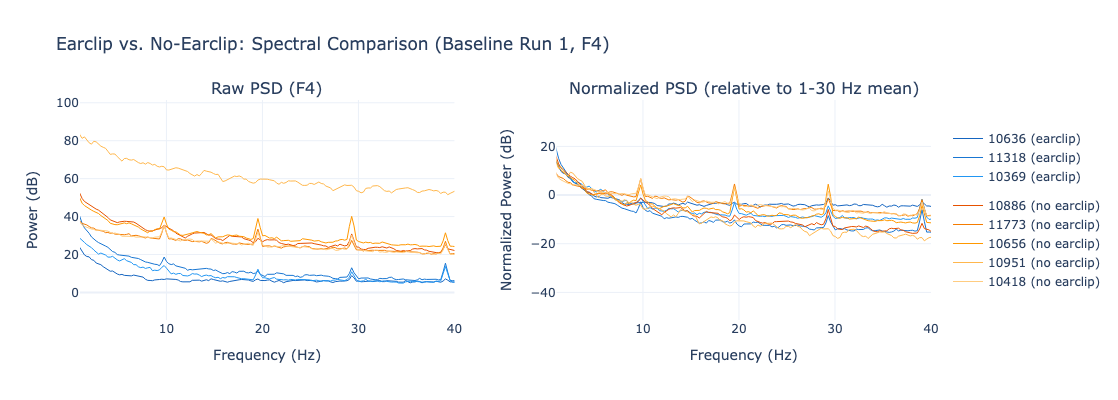

In [18]:
# =============================================================================
# A3. Visual Comparison: Raw PSD Overlay (Earclip vs No-Earclip)
# =============================================================================
#
# Plot average PSD for each group to see where spectral characteristics differ.

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Raw PSD (F4)', 'Normalized PSD (relative to 1-30 Hz mean)'],
    horizontal_spacing=0.12,
)

# Color palettes
ec_colors = ['#1565C0', '#1976D2', '#2196F3']  # Blues for earclip
ne_colors = ['#E65100', '#F57C00', '#FF9800', '#FFB74D', '#FFCC80', '#FFE0B2']  # Oranges for no-earclip

# Plot individual subjects
for i, m in enumerate(earclip_metrics):
    fig.add_trace(go.Scatter(
        x=m['freqs'], y=10 * np.log10(m['psd'] + 1e-30),
        mode='lines', line=dict(color=ec_colors[i % len(ec_colors)], width=1),
        name=f'{m["subject_id"]} (earclip)',
        legendgroup='earclip',
    ), row=1, col=1)

for i, m in enumerate(no_earclip_metrics):
    fig.add_trace(go.Scatter(
        x=m['freqs'], y=10 * np.log10(m['psd'] + 1e-30),
        mode='lines', line=dict(color=ne_colors[i % len(ne_colors)], width=1),
        name=f'{m["subject_id"]} (no earclip)',
        legendgroup='no_earclip',
    ), row=1, col=1)

# Normalized PSDs (remove overall power differences)
for i, m in enumerate(earclip_metrics):
    psd_norm = m['psd'] / np.mean(m['psd'][(m['freqs'] >= 1) & (m['freqs'] <= 30)])
    fig.add_trace(go.Scatter(
        x=m['freqs'], y=10 * np.log10(psd_norm + 1e-30),
        mode='lines', line=dict(color=ec_colors[i % len(ec_colors)], width=1),
        name=f'{m["subject_id"]} (earclip)',
        legendgroup='earclip',
        showlegend=False,
    ), row=1, col=2)

for i, m in enumerate(no_earclip_metrics):
    psd_norm = m['psd'] / np.mean(m['psd'][(m['freqs'] >= 1) & (m['freqs'] <= 30)])
    fig.add_trace(go.Scatter(
        x=m['freqs'], y=10 * np.log10(psd_norm + 1e-30),
        mode='lines', line=dict(color=ne_colors[i % len(ne_colors)], width=1),
        name=f'{m["subject_id"]} (no earclip)',
        legendgroup='no_earclip',
        showlegend=False,
    ), row=1, col=2)

fig.update_xaxes(range=[1, 40], title_text='Frequency (Hz)', row=1, col=1)
fig.update_xaxes(range=[1, 40], title_text='Frequency (Hz)', row=1, col=2)
fig.update_yaxes(title_text='Power (dB)', row=1, col=1)
fig.update_yaxes(title_text='Normalized Power (dB)', row=1, col=2)

fig.update_layout(
    height=400, width=1000,
    template='plotly_white',
    title='Earclip vs. No-Earclip: Spectral Comparison (Baseline Run 1, F4)',
    legend=dict(x=1.02, y=0.5),
)

fig.show()

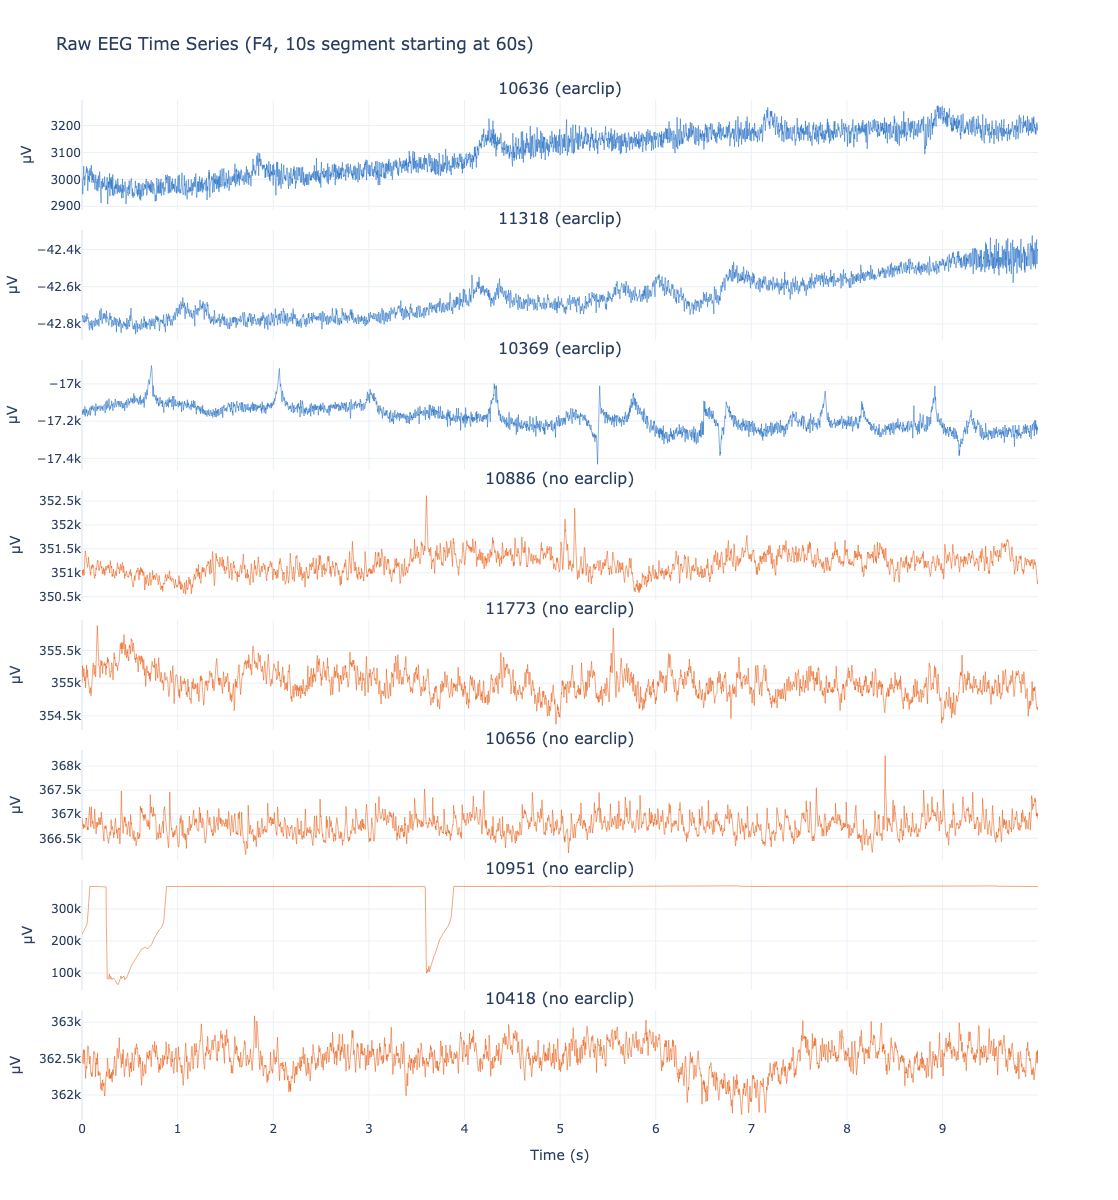


Interpretation guide:
- Earclip data (blue) may show different DC offsets due to hardware reference
- No-earclip data (orange) often shows more drift and common-mode noise
- Both should show similar oscillatory patterns after preprocessing


In [20]:
# =============================================================================
# A4. Time-Domain Comparison: Raw Signal Segments
# =============================================================================
#
# Plot 10-second segments of raw EEG to visualize:
# - DC offset differences
# - Drift patterns
# - Noise characteristics

segment_start = 60  # Start at 60 seconds (after any initial transients)
segment_duration = 10  # 10 seconds
samples_per_segment = int(segment_duration * FS)
start_sample = int(segment_start * FS)
end_sample = start_sample + samples_per_segment

n_earclip = len(earclip_baselines)
n_no_earclip = len(no_earclip_baselines)
n_total = n_earclip + n_no_earclip

fig = make_subplots(
    rows=n_total, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.02,
    subplot_titles=(
        [f'{b["subject_id"]} (earclip)' for b in earclip_baselines] +
        [f'{b["subject_id"]} (no earclip)' for b in no_earclip_baselines]
    ),
)

time_axis = np.arange(samples_per_segment) / FS

row = 1
for baseline in earclip_baselines:
    eeg_segment = baseline['eeg_raw'][start_sample:end_sample, 0] / 1000  # F4, convert to µV
    fig.add_trace(go.Scatter(
        x=time_axis, y=eeg_segment,
        mode='lines', line=dict(color='#1565C0', width=0.5),
        name=baseline['subject_id'],
    ), row=row, col=1)
    fig.update_yaxes(title_text='µV', row=row, col=1)
    row += 1

for baseline in no_earclip_baselines:
    eeg_segment = baseline['eeg_raw'][start_sample:end_sample, 0] / 1000  # F4, convert to µV
    fig.add_trace(go.Scatter(
        x=time_axis, y=eeg_segment,
        mode='lines', line=dict(color='#E65100', width=0.5),
        name=baseline['subject_id'],
    ), row=row, col=1)
    fig.update_yaxes(title_text='µV', row=row, col=1)
    row += 1

fig.update_xaxes(title_text='Time (s)', row=n_total, col=1)
fig.update_layout(
    height=150 * n_total,
    width=1000,
    template='plotly_white',
    title=f'Raw EEG Time Series (F4, {segment_duration}s segment starting at {segment_start}s)',
    showlegend=False,
)

fig.show()

print('\nInterpretation guide:')
print('- Earclip data (blue) may show different DC offsets due to hardware reference')
print('- No-earclip data (orange) often shows more drift and common-mode noise')
print('- Both should show similar oscillatory patterns after preprocessing')

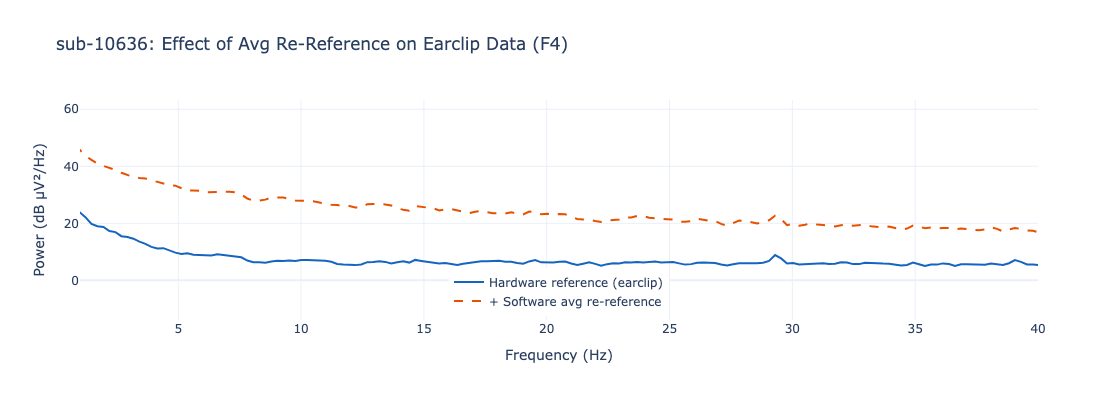


Effect of avg re-referencing on earclip data:
  Mean power change: 22.59 dB
  Interpretation: Substantial change (investigate)


In [22]:
# =============================================================================
# A5. Effect of Re-Referencing on Earclip Data
# =============================================================================
#
# Should we apply avg re-referencing to earclip participants?
# Compare: raw earclip data vs. avg-rereferenced earclip data
#
# If the earclip reference is working well, avg re-referencing should:
# - Have minimal effect on the spectrum (already well-referenced)
# - Potentially attenuate signals (removing shared real neural activity)
#
# If earclip reference has issues, avg re-referencing might:
# - Remove residual common-mode noise
# - Change the spectrum substantially

if len(earclip_baselines) > 0:
    # Pick first earclip subject for demonstration
    demo_baseline = earclip_baselines[0]
    subject_id = demo_baseline['subject_id']
    
    # Raw (hardware referenced)
    eeg_raw = demo_baseline['eeg_raw'][:, 0]  # F4
    
    # Apply avg re-reference to the raw data (as if no earclip)
    eeg_avg_reref = avg_rereference(demo_baseline['eeg'])[:, 0]  # F4
    
    # Compute PSDs
    freqs, psd_raw = signal.welch(signal.detrend(eeg_raw / 1000), fs=FS, nperseg=2048)
    _, psd_reref = signal.welch(signal.detrend(eeg_avg_reref / 1000), fs=FS, nperseg=2048)
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=freqs, y=10 * np.log10(psd_raw + 1e-30),
        mode='lines', line=dict(color='#1565C0', width=2),
        name='Hardware reference (earclip)',
    ))
    
    fig.add_trace(go.Scatter(
        x=freqs, y=10 * np.log10(psd_reref + 1e-30),
        mode='lines', line=dict(color='#E65100', width=2, dash='dash'),
        name='+ Software avg re-reference',
    ))
    
    fig.update_xaxes(range=[1, 40], title_text='Frequency (Hz)')
    fig.update_yaxes(title_text='Power (dB µV²/Hz)')
    fig.update_layout(
        height=400, width=700,
        template='plotly_white',
        title=f'sub-{subject_id}: Effect of Avg Re-Reference on Earclip Data (F4)',
        legend=dict(x=0.5, y=0.02, xanchor='center'),
    )
    
    fig.show()
    
    # Quantify the difference
    power_change_db = 10 * np.log10(np.mean(psd_reref) / np.mean(psd_raw))
    print(f'\nEffect of avg re-referencing on earclip data:')
    print(f'  Mean power change: {power_change_db:.2f} dB')
    print(f'  Interpretation: {"Minimal change (good)" if abs(power_change_db) < 3 else "Substantial change (investigate)"}')
else:
    print('No earclip participants loaded for comparison.')

---
# PART B: Group-Level Analysis

Process all subjects in the sample and aggregate results for:
1. ITF extraction per subject
2. Protocol compliance verification
3. Summary statistics across the sample

In [25]:
# =============================================================================
# B1. Spectral Parameterization Utilities
# =============================================================================

from specparam import SpectralModel

def compute_aperiodic_fit(freqs, aperiodic_params):
    """Reconstruct the aperiodic (1/f) component from fitted parameters."""
    offset, exponent = aperiodic_params
    return offset - np.log10(freqs ** exponent)


def preprocess_eeg(eeg_data, fs=FS, lowcut=1.0, highcut=40.0, notch_freq=60.0):
    """Bandpass + notch filter."""
    from scipy.signal import butter, filtfilt, iirnotch
    
    nyq = fs / 2
    b, a = butter(4, [lowcut / nyq, highcut / nyq], btype='band')
    filtered = filtfilt(b, a, eeg_data.astype(float))
    
    if notch_freq is not None:
        b_notch, a_notch = iirnotch(notch_freq, Q=30, fs=fs)
        filtered = filtfilt(b_notch, a_notch, filtered)
    
    return filtered


def reject_artifacts(eeg_data, threshold_uv=150):
    """Simple amplitude-based artifact rejection."""
    if np.abs(eeg_data).max() > 1e6:
        eeg_uv = eeg_data / 1000
    else:
        eeg_uv = eeg_data
    
    clean_mask = np.abs(eeg_uv) < threshold_uv
    pct_rejected = 100 * (1 - clean_mask.mean())
    
    return clean_mask, pct_rejected


def compute_psd(eeg_data, fs=FS, nperseg=2048, preprocess=True):
    """Compute PSD using Welch's method with optional preprocessing."""
    if preprocess:
        data = preprocess_eeg(eeg_data, fs=fs)
        clean_mask, pct_rej = reject_artifacts(data)
        if pct_rej > 50:
            warnings.warn(f'{pct_rej:.1f}% of samples rejected as artifacts')
        data = data[clean_mask]
    else:
        data = signal.detrend(eeg_data.astype(float))
    
    freqs, psd = signal.welch(data, fs=fs, nperseg=nperseg, noverlap=nperseg//2)
    return freqs, psd


def fit_specparam(freqs, psd, freq_range=(1, 50)):
    """Fit a specparam model to a PSD."""
    sm = SpectralModel(
        peak_width_limits=(0.5, 4),
        max_n_peaks=4,
        min_peak_height=0.15,
        aperiodic_mode='fixed',
        verbose=False,
    )
    sm.fit(freqs, psd, freq_range)
    return sm


def extract_itf(model, theta_range=(4, 8)):
    """Extract individual theta frequency from fitted specparam model."""
    peaks = model.results.params.periodic.params
    
    if peaks.ndim == 1:
        if len(peaks) == 0:
            return {'itf': None, 'power': None, 'bandwidth': None, 'has_theta': False}
        peaks = peaks.reshape(1, -1)
    
    if len(peaks) == 0:
        return {'itf': None, 'power': None, 'bandwidth': None, 'has_theta': False}
    
    theta_peaks = peaks[(peaks[:, 0] >= theta_range[0]) &
                        (peaks[:, 0] <= theta_range[1])]
    
    if len(theta_peaks) == 0:
        return {'itf': None, 'power': None, 'bandwidth': None, 'has_theta': False}
    
    best = theta_peaks[np.argmax(theta_peaks[:, 1])]
    return {
        'itf': best[0],
        'power': best[1],
        'bandwidth': best[2],
        'has_theta': True,
    }


print('Specparam utilities loaded.')

Specparam utilities loaded.


In [27]:
# =============================================================================
# B2. Process All Subjects — Extract ITF and Protocol Compliance
# =============================================================================

def process_subject(subject_id, eeg_dir=EEG_DIR):
    """
    Process a single subject: load all runs, verify protocol, extract ITF.
    
    Returns a dict with:
    - Protocol compliance info for each run
    - ITF estimates from baseline runs
    - Signal quality metrics
    """
    sub_info = SUBJECT_INFO[subject_id]
    cb_order = sub_info['counterbalance']
    has_earclip = sub_info['earclip']
    condition_map = RUN_CONDITIONS[cb_order]
    
    run_files = discover_runs(eeg_dir, subject_id)
    
    if len(run_files) == 0:
        return {'subject_id': subject_id, 'error': 'No runs found'}
    
    results = {
        'subject_id': subject_id,
        'counterbalance': cb_order,
        'has_earclip': has_earclip,
        'n_runs': len(run_files),
        'runs': {},
        'protocol_mismatches': [],
        'itf_estimates': {},
    }
    
    # Process each run
    for run_num in sorted(run_files.keys()):
        files = run_files[run_num]
        
        try:
            nic2 = load_nic2_run(files['easy'], files['info'], files['imp'])
        except Exception as e:
            results['runs'][run_num] = {'error': str(e)}
            continue
        
        expected_condition = condition_map.get(run_num, 'unknown')
        detected_active = detect_active_stim(nic2['eeg'], nic2['stim_mask'])
        expected_active = expected_condition == 'active'
        
        run_result = {
            'condition': expected_condition,
            'detected_active': detected_active,
            'protocol_match': detected_active == expected_active,
            'duration_s': (nic2['timestamps'][-1] - nic2['timestamps'][0]) / 1000,
        }
        
        if not run_result['protocol_match']:
            results['protocol_mismatches'].append(run_num)
        
        # Extract ITF from baseline runs only
        if expected_condition == 'baseline':
            if not has_earclip:
                eeg_reref = avg_rereference(nic2['eeg'])
            else:
                eeg_reref = nic2['eeg'][:, EEG_CH_IDX].astype(float)
            
            # Compute ITF for F4 (primary channel)
            f4_data = eeg_reref[:, 0]
            try:
                freqs, psd = compute_psd(f4_data, preprocess=True)
                model = fit_specparam(freqs, 10 * np.log10(psd + 1e-30))
                itf_result = extract_itf(model)
                r_squared = model.results.metrics.results['gof_rsquared']
                
                run_result['itf'] = itf_result['itf']
                run_result['itf_power'] = itf_result['power']
                run_result['has_theta'] = itf_result['has_theta']
                run_result['r_squared'] = r_squared
                
                # Store for subject-level aggregation
                if itf_result['has_theta'] and r_squared >= 0.85:
                    if 'F4' not in results['itf_estimates']:
                        results['itf_estimates']['F4'] = []
                    results['itf_estimates']['F4'].append(itf_result['itf'])
                    
            except Exception as e:
                run_result['itf_error'] = str(e)
        
        results['runs'][run_num] = run_result
    
    # Compute subject-level ITF (median across valid baseline runs)
    if 'F4' in results['itf_estimates'] and len(results['itf_estimates']['F4']) > 0:
        results['itf_f4'] = np.median(results['itf_estimates']['F4'])
        results['itf_f4_n'] = len(results['itf_estimates']['F4'])
    else:
        results['itf_f4'] = None
        results['itf_f4_n'] = 0
    
    return results


# Process all subjects
all_subject_results = []

print('Processing all subjects...')
print('=' * 60)

for subject_id in SUBJECT_INFO.keys():
    print(f'\nsub-{subject_id}...')
    result = process_subject(subject_id)
    all_subject_results.append(result)
    
    if 'error' in result:
        print(f'  ERROR: {result["error"]}')
        continue
    
    print(f'  Runs: {result["n_runs"]}, Earclip: {result["has_earclip"]}')
    print(f'  Protocol mismatches: {result["protocol_mismatches"] if result["protocol_mismatches"] else "None"}')
    print(f'  ITF (F4): {result["itf_f4"]:.2f} Hz (n={result["itf_f4_n"]})' if result['itf_f4'] else '  ITF (F4): Not detected')

print('\n' + '=' * 60)
print('Processing complete.')

Processing all subjects...

sub-10886...
  Runs: 8, Earclip: False
  Protocol mismatches: None
  ITF (F4): Not detected

sub-10998...


/var/folders/m6/p7f91dqd37d_mdjnjbx6xdy80000gn/T/ipykernel_98857/3621699443.py:47: UserWarning:

96.8% of samples rejected as artifacts



  Runs: 7, Earclip: False
  Protocol mismatches: [6]
  ITF (F4): Not detected

sub-11773...


/var/folders/m6/p7f91dqd37d_mdjnjbx6xdy80000gn/T/ipykernel_98857/3621699443.py:47: UserWarning:

95.7% of samples rejected as artifacts



  Runs: 8, Earclip: False
  Protocol mismatches: [6, 7]
  ITF (F4): Not detected

sub-10656...


...

  Runs: 8, Earclip: False
  Protocol mismatches: None
  ITF (F4): Not detected

sub-10951...
  Runs: 8, Earclip: False
  Protocol mismatches: None
  ITF (F4): Not detected

sub-10418...


/var/folders/m6/p7f91dqd37d_mdjnjbx6xdy80000gn/T/ipykernel_98857/3621699443.py:47: UserWarning:

95.7% of samples rejected as artifacts

/var/folders/m6/p7f91dqd37d_mdjnjbx6xdy80000gn/T/ipykernel_98857/3621699443.py:47: UserWarning:

95.1% of samples rejected as artifacts



  Runs: 8, Earclip: False
  Protocol mismatches: None
  ITF (F4): Not detected

sub-10636...


/var/folders/m6/p7f91dqd37d_mdjnjbx6xdy80000gn/T/ipykernel_98857/3621699443.py:47: UserWarning:

99.1% of samples rejected as artifacts

/opt/anaconda3/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:600: UserWarning:

nperseg = 2048 is greater than input length  = 1699, using nperseg = 1699

/opt/anaconda3/lib/python3.12/site-packages/specparam/data/data.py:300: RuntimeWarning:

invalid value encountered in log10



  Runs: 8, Earclip: True
  Protocol mismatches: [6, 7]
  ITF (F4): Not detected

sub-11318...
  Runs: 8, Earclip: True
  Protocol mismatches: None
  ITF (F4): Not detected

sub-10369...
  Runs: 8, Earclip: True
  Protocol mismatches: None
  ITF (F4): Not detected

Processing complete.


In [29]:
# =============================================================================
# B3. Group Summary Table
# =============================================================================

summary_rows = []

for result in all_subject_results:
    if 'error' in result:
        summary_rows.append({
            'subject_id': result['subject_id'],
            'status': 'ERROR',
        })
        continue
    
    summary_rows.append({
        'subject_id': result['subject_id'],
        'counterbalance': result['counterbalance'],
        'earclip': result['has_earclip'],
        'n_runs': result['n_runs'],
        'protocol_ok': len(result['protocol_mismatches']) == 0,
        'itf_f4': result['itf_f4'],
        'itf_n': result['itf_f4_n'],
    })

summary_df = pd.DataFrame(summary_rows)

print('\nGroup Summary')
print('=' * 90)
print(summary_df.to_string(index=False))
print()

# Aggregate statistics
valid_itf = summary_df.dropna(subset=['itf_f4'])

if len(valid_itf) > 0:
    print('ITF Statistics (F4, baseline runs):')
    print(f'  N with valid ITF: {len(valid_itf)} / {len(summary_df)}')
    print(f'  Mean ITF: {valid_itf["itf_f4"].mean():.2f} Hz')
    print(f'  SD: {valid_itf["itf_f4"].std():.2f} Hz')
    print(f'  Range: {valid_itf["itf_f4"].min():.2f} – {valid_itf["itf_f4"].max():.2f} Hz')
    print(f'  Distance from 6 Hz tACS: {abs(valid_itf["itf_f4"].mean() - 6):.2f} Hz (mean)')
    
    # By earclip status
    earclip_itf = valid_itf[valid_itf['earclip'] == True]['itf_f4']
    no_earclip_itf = valid_itf[valid_itf['earclip'] == False]['itf_f4']
    
    print()
    print('By reference type:')
    if len(earclip_itf) > 0:
        print(f'  Earclip (n={len(earclip_itf)}): {earclip_itf.mean():.2f} ± {earclip_itf.std():.2f} Hz')
    if len(no_earclip_itf) > 0:
        print(f'  No earclip (n={len(no_earclip_itf)}): {no_earclip_itf.mean():.2f} ± {no_earclip_itf.std():.2f} Hz')


Group Summary
subject_id counterbalance  earclip  n_runs  protocol_ok itf_f4  itf_n
     10886              B    False       8         True   None      0
     10998              B    False       7        False   None      0
     11773              B    False       8        False   None      0
     10656              A    False       8         True   None      0
     10951              A    False       8         True   None      0
     10418              B    False       8         True   None      0
     10636              B     True       8        False   None      0
     11318              B     True       8         True   None      0
     10369              B     True       8         True   None      0



In [31]:
# =============================================================================
# B4. ITF Distribution Plot
# =============================================================================

valid_itf = summary_df.dropna(subset=['itf_f4'])

if len(valid_itf) > 0:
    fig = go.Figure()
    
    # Separate by earclip status
    earclip_df = valid_itf[valid_itf['earclip'] == True]
    no_earclip_df = valid_itf[valid_itf['earclip'] == False]
    
    # No earclip subjects
    if len(no_earclip_df) > 0:
        fig.add_trace(go.Scatter(
            x=no_earclip_df['itf_f4'],
            y=['No earclip'] * len(no_earclip_df),
            mode='markers',
            marker=dict(size=12, color='#E65100', symbol='circle'),
            text=no_earclip_df['subject_id'],
            name='No earclip',
            hovertemplate='%{text}: %{x:.2f} Hz<extra></extra>',
        ))
    
    # Earclip subjects
    if len(earclip_df) > 0:
        fig.add_trace(go.Scatter(
            x=earclip_df['itf_f4'],
            y=['Earclip'] * len(earclip_df),
            mode='markers',
            marker=dict(size=12, color='#1565C0', symbol='circle'),
            text=earclip_df['subject_id'],
            name='Earclip',
            hovertemplate='%{text}: %{x:.2f} Hz<extra></extra>',
        ))
    
    # Add tACS frequency reference line
    fig.add_vline(x=6.0, line=dict(color='#CC0000', width=2, dash='dash'),
                  annotation_text='tACS (6 Hz)', annotation_position='top')
    
    # Theta band boundaries
    fig.add_vrect(x0=4, x1=8, fillcolor='rgba(0,100,0,0.1)', line_width=0,
                  annotation_text='Theta band', annotation_position='bottom right')
    
    fig.update_xaxes(range=[3, 10], title_text='Individual Theta Frequency (Hz)')
    fig.update_layout(
        height=300, width=700,
        template='plotly_white',
        title='ITF Distribution by Reference Type',
        yaxis_title='',
        legend=dict(x=1.02, y=0.5),
    )
    
    fig.show()
else:
    print('No valid ITF estimates to plot.')

No valid ITF estimates to plot.


In [33]:
# =============================================================================
# B5. Export Group Results to CSV
# =============================================================================

output_dir = REPO_ROOT / 'derivatives' / 'eeg'
output_dir.mkdir(parents=True, exist_ok=True)

# Main summary
summary_path = output_dir / 'group_eeg_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f'Saved: {summary_path}')

# Detailed per-run results
run_rows = []
for result in all_subject_results:
    if 'runs' not in result:
        continue
    for run_num, run_data in result['runs'].items():
        row = {
            'subject_id': result['subject_id'],
            'run': run_num,
            'counterbalance': result['counterbalance'],
            'earclip': result['has_earclip'],
            **run_data,
        }
        run_rows.append(row)

if run_rows:
    run_df = pd.DataFrame(run_rows)
    run_path = output_dir / 'group_eeg_runs.csv'
    run_df.to_csv(run_path, index=False)
    print(f'Saved: {run_path}')

Saved: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/group_eeg_summary.csv
Saved: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/group_eeg_runs.csv


---
## Summary

### Part A: Earclip Investigation

The earclip (CMS/DRL) provides a hardware reference that fundamentally changes the signal characteristics:

1. **Inter-channel correlation**: Without earclip, channels share more variance (higher correlation) because of the floating reference. After avg re-referencing, this is removed but at the cost of creating mathematical dependencies.

2. **Spectral shape**: The 1/f slope and overall power levels may differ between groups due to different noise floors.

3. **Visual appearance**: Earclip data may look "less intuitive" because it doesn't have the drift patterns that no-earclip data shows. This is actually a sign of better data quality.

**Recommendation**: Process earclip and no-earclip participants separately in analyses, or include reference type as a covariate. The ITF estimates from earclip participants are likely more reliable.

### Part B: Group-Level Analysis

The batch processing pipeline extracts:
- Protocol compliance for each run (active vs sham verification)
- ITF estimates from baseline runs
- Summary statistics across the sample

Results are exported to CSV for integration with the behavioral analysis notebook.